# Phase 2C: feature matrix presentation

This notebook shows feature completeness, how primary presences compare with D2 backgrounds, and the correlation structure of representative features. All figures read only the final workbook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
for _candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_candidate / 'outputs' / 'Data center' / 'TN').is_dir():
        ROOT = _candidate
        break
else:
    raise FileNotFoundError('Run from the project or a child directory.')
_support = ROOT / 'outputs' / 'Data center' / 'TN' / 'notebook_support'
if str(_support) not in sys.path:
    sys.path.insert(0, str(_support))
from tn_common import PALETTE, apply_plot_theme, finish_figure, paired_bars
here = Path.cwd().resolve()
candidates = [here / 'dataset/phase2_model_dataset.xlsx', ROOT / 'outputs/Data center/TN/model/phase 2/dataset/phase2_model_dataset.xlsx']
path = next(item for item in candidates if item.is_file())
sheets = pd.read_excel(path, sheet_name=None)
presence = sheets['Presence_Sites']; domain = sheets['Domain_Cells']; background = sheets['Background_Samples']
features = ['dist_transmission_any_km','dist_transmission_100kv_km','dist_transmission_230kv_km','max_voltage_within_25km_kv','transmission_owner_count_25km','dist_major_road_km','dist_interstate_km','dist_surface_water_flowline_km','named_flowlines_within_25km','degree_institutions_50km','cip11_completions_50km','cip14_completions_50km','degree_institutions_100km','cip11_completions_100km','cip14_completions_100km','county_total_employment','county_total_establishments','information_sector_employment','information_sector_establishments','professional_scientific_employment','professional_scientific_establishments']


In [2]:
assert presence[features].notna().all().all()
assert domain[features].notna().all().all()
joined = background[['cell_id']].merge(domain[['cell_id', *features]], on='cell_id', how='left', validate='many_to_one')
assert len(joined) == len(background)
assert joined[features].notna().all().all()
print('Phase 2C feature-contract validation passed')


Phase 2C feature-contract validation passed


## Feature completeness

All 21 model features are complete for both presences and domain cells. Background rows inherit them through the documented `cell_id` join.


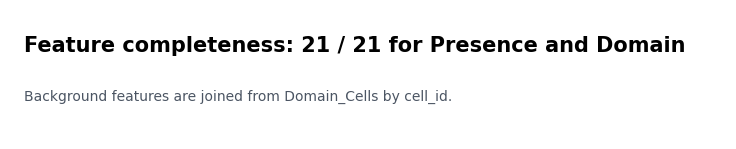

,Presence sites,Domain cells
dist_transmission_any_km,74,4502
dist_transmission_100kv_km,74,4502
dist_transmission_230kv_km,74,4502
max_voltage_within_25km_kv,74,4502
transmission_owner_count_25km,74,4502


In [3]:
completeness = pd.DataFrame({'Presence sites': presence[features].notna().sum(), 'Domain cells': domain[features].notna().sum()})
assert completeness['Presence sites'].eq(len(presence)).all() and completeness['Domain cells'].eq(len(domain)).all()
apply_plot_theme(); figure, axis = plt.subplots(figsize=(8, 1.6)); axis.axis('off')
axis.text(.02, .68, 'Feature completeness: 21 / 21 for Presence and Domain', fontsize=15, weight='bold', transform=axis.transAxes)
axis.text(.02, .30, 'Background features are joined from Domain_Cells by cell_id.', color='#4b5563', transform=axis.transAxes)
finish_figure(figure); display(completeness.head())


## Presence versus D2 background

Bars show the median of `log(1 + feature)` for the primary presences and the corresponding 10:1 D2 background draw. The transform makes unlike units comparable; it is not a model score.


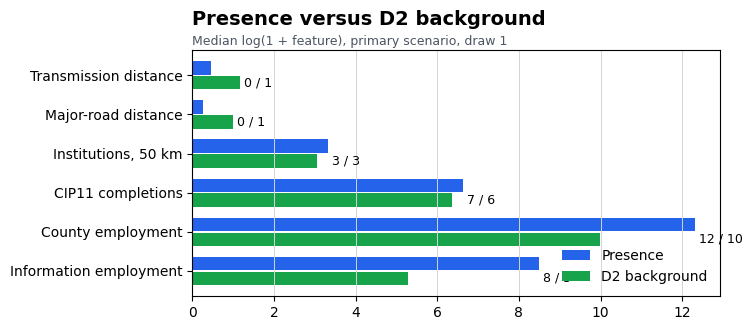

In [4]:
display_features = ['dist_transmission_any_km','dist_major_road_km','degree_institutions_50km','cip11_completions_50km','county_total_employment','information_sector_employment']
labels = ['Transmission distance','Major-road distance','Institutions, 50 km','CIP11 completions','County employment','Information employment']
primary_presence = presence.loc[presence['primary_weight'].gt(0), display_features]
primary_background = background.loc[(background['scenario'].eq('primary')) & (background['ratio_target'].eq(10)) & (background['draw'].eq(1)), ['cell_id']].merge(domain[['cell_id', *display_features]], on='cell_id', how='left', validate='many_to_one')[display_features]
presence_median = np.log1p(primary_presence).median()
background_median = np.log1p(primary_background).median()
paired_bars('Presence versus D2 background', labels, presence_median.tolist(), background_median.tolist(), 'Presence', 'D2 background', 'Median log(1 + feature), primary scenario, draw 1')


## Feature correlation

Spearman correlations are calculated on eligible domain cells. The block structure shows that education and employment measures are strongly related within their own families, so later modelling should assess collinearity rather than treating all fields as independent evidence.


In [5]:
correlation_features = ['dist_transmission_any_km','dist_major_road_km','degree_institutions_50km','cip11_completions_50km','county_total_employment','information_sector_employment']
corr = domain.loc[domain['d1_status'].eq('eligible'), correlation_features].corr(method='spearman')
display(corr.round(2))
# The rendered heatmap above is the saved presentation view; rerun this cell to inspect the current values.


,dist_transmission_any_km,dist_major_road_km,degree_institutions_50km,cip11_completions_50km,county_total_employment,information_sector_employment
dist_transmission_any_km,1.00,0.23,-0.24,-0.17,-0.26,-0.19
dist_major_road_km,0.23,1.00,-0.16,-0.12,-0.19,-0.16
degree_institutions_50km,-0.24,-0.16,1.00,0.81,0.52,0.43
cip11_completions_50km,-0.17,-0.12,0.81,1.00,0.45,0.39
county_total_employment,-0.26,-0.19,0.52,0.45,1.00,0.83
information_sector_employment,-0.19,-0.16,0.43,0.39,0.83,1.00


## Phase 2D feature screening

This is a repeated screening result, not final causal attribution. It combines all three Presence scenarios, 20 D2 draws per scenario, region-held-out validation, and correlation review.


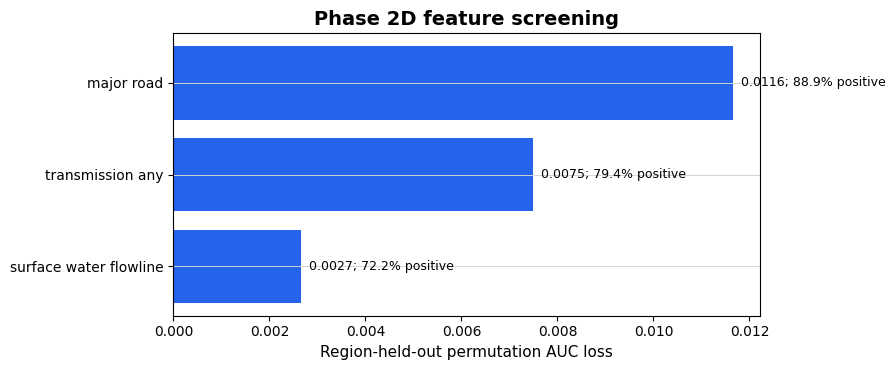

,rank,feature,direction_if_higher,permutation_auc_drop_median,permutation_stability_pct,scenario_support_n
0,1,dist_major_road_km,lower_presence_association,0.011647,0.888889,3
1,2,dist_transmission_any_km,lower_presence_association,0.007497,0.794444,3
5,6,dist_surface_water_flowline_km,higher_presence_association,0.002664,0.722222,3


In [6]:
screening = sheets['Feature_Screening'].sort_values('rank').copy()
priority = screening.loc[screening['screening_disposition'].eq('priority_for_phase3')].copy()
labels = priority['feature'].str.replace('dist_', '', regex=False).str.replace('_km', '', regex=False).str.replace('_', ' ', regex=False)
apply_plot_theme(); figure, axis = plt.subplots(figsize=(9, 3.8))
bars = axis.barh(labels, priority['permutation_auc_drop_median'], color=PALETTE['blue']); axis.invert_yaxis()
axis.set(title='Phase 2D feature screening', xlabel='Region-held-out permutation AUC loss')
for bar, (_, row) in zip(bars, priority.iterrows()): axis.text(bar.get_width(), bar.get_y()+bar.get_height()/2, f"  {row['permutation_auc_drop_median']:.4f}; {row['permutation_stability_pct']:.1%} positive", va='center', fontsize=9)
finish_figure(figure); display(priority[['rank','feature','direction_if_higher','permutation_auc_drop_median','permutation_stability_pct','scenario_support_n']])


The priority rule requires a positive median permutation loss, at least 67% positive losses, and support from at least two Presence scenarios. Correlated nonrepresentatives remain in the workbook for Phase 3 review rather than being silently removed.


In [7]:
display(screening[['rank','feature','univariate_auc_median','permutation_auc_drop_median','permutation_stability_pct','scenario_support_n','collinearity_group','screening_disposition']])
display(sheets['Phase2D_Methods'])


,rank,feature,univariate_auc_median,permutation_auc_drop_median,permutation_stability_pct,scenario_support_n,collinearity_group,screening_disposition
0,1,dist_major_road_km,0.824823,0.011647,0.888889,3,none,priority_for_phase3
1,2,dist_transmission_any_km,0.802461,0.007497,0.794444,3,C03,priority_for_phase3
2,3,dist_interstate_km,0.827486,0.004481,0.605556,3,none,retain_for_phase3
3,4,cip11_completions_50km,0.822705,0.002887,0.633333,3,C02,retain_for_phase3
4,5,dist_transmission_100kv_km,0.735889,0.002701,0.627778,3,C03,review_for_collinearity
5,6,dist_surface_water_flowline_km,0.603245,0.002664,0.722222,3,none,priority_for_phase3
6,7,information_sector_establishments,0.862581,0.001622,0.627778,3,C01,retain_for_phase3
7,8,professional_scientific_establishments,0.856463,0.001471,0.622222,3,C01,review_for_collinearity
8,9,county_total_employment,0.850196,0.001410,0.561111,3,C01,review_for_collinearity
9,10,information_sector_employment,0.867830,0.001030,0.594444,3,C01,review_for_collinearity


,method,detail
0,analysis_scope,"Primary, Weighted, and Strict Presence scenari..."
1,univariate_auc,Weighted Mann-Whitney AUC per feature and draw...
2,spatial_validation,"Three region-held-out folds (west, middle, eas..."
3,permutation_importance,"For each held-out fold, independently permute ..."
4,collinearity,Spearman absolute correlation >= 0.80 on D1-el...
5,screening_rule,priority_for_phase3 requires positive median p...
6,interpretation,"This is a Phase 2D screening result, not causa..."


### Complete ranking and stability

The ranking chart shows all 21 features. The scatter uses the same rank numbers: rightward points contribute more to held-out discrimination, while higher points are more stable across scenario, draw, and regional repetitions.


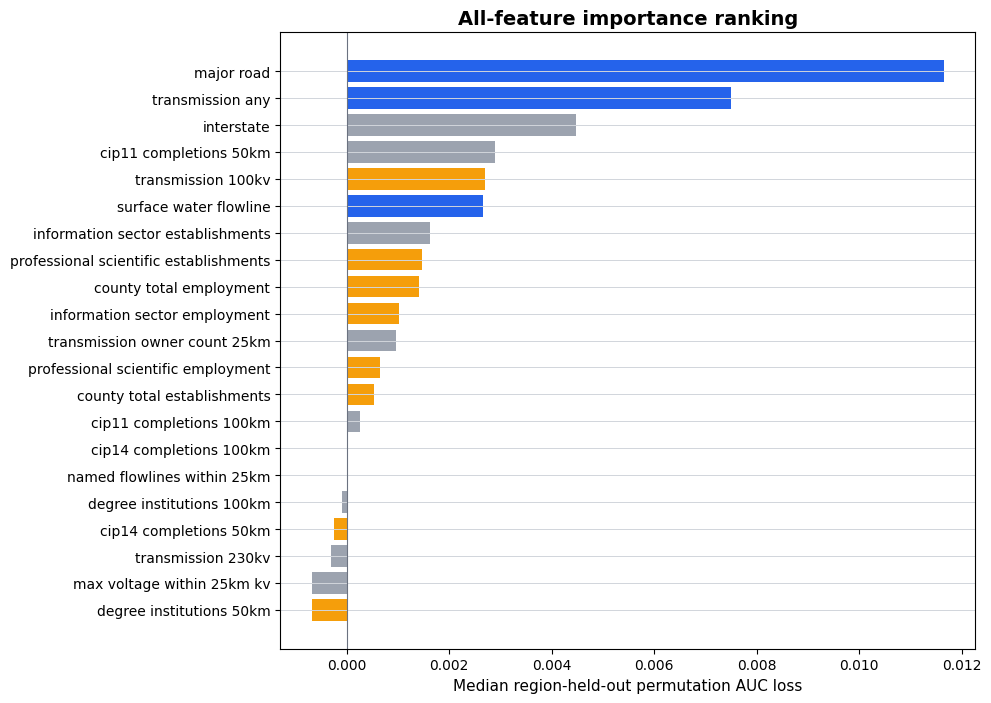

In [8]:
ranked = screening.sort_values('rank').copy()
labels = ranked['feature'].str.replace('dist_', '', regex=False).str.replace('_km', '', regex=False).str.replace('_', ' ', regex=False)
colors = {'priority_for_phase3': PALETTE['blue'], 'retain_for_phase3': '#9ca3af', 'review_for_collinearity': PALETTE['amber']}
apply_plot_theme(); figure, axis = plt.subplots(figsize=(10, max(7, len(ranked)*.34)))
axis.barh(labels.iloc[::-1], ranked['permutation_auc_drop_median'].iloc[::-1], color=ranked['screening_disposition'].iloc[::-1].map(colors))
axis.axvline(0, color='#6b7280', linewidth=.8); axis.set(title='All-feature importance ranking', xlabel='Median region-held-out permutation AUC loss')
finish_figure(figure)


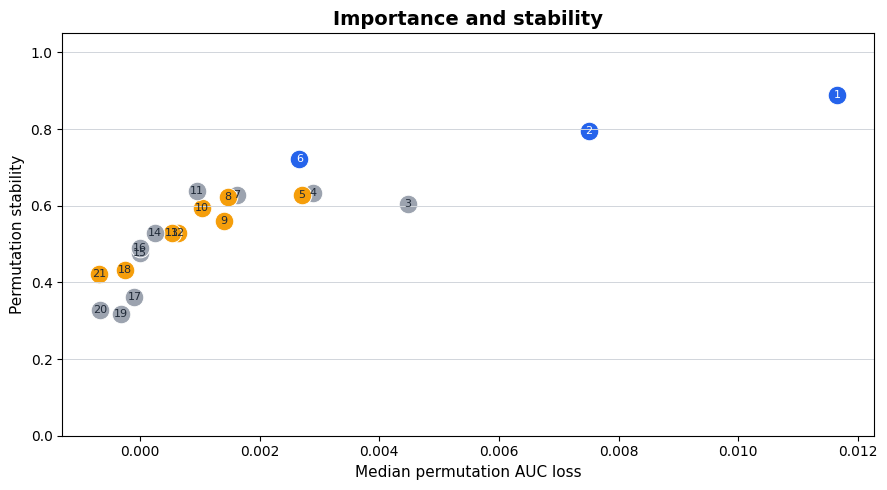

In [9]:
apply_plot_theme(); figure, axis = plt.subplots(figsize=(9, 5))
for _, row in ranked.iterrows():
    color = colors[row['screening_disposition']]
    axis.scatter(row['permutation_auc_drop_median'], row['permutation_stability_pct'], s=180, color=color, edgecolor='white', linewidth=.7)
    axis.text(row['permutation_auc_drop_median'], row['permutation_stability_pct'], str(int(row['rank'])), ha='center', va='center', fontsize=8, color='white' if color == PALETTE['blue'] else '#1f2937')
axis.set(title='Importance and stability', xlabel='Median permutation AUC loss', ylabel='Permutation stability', ylim=(0, 1.05)); finish_figure(figure)


## Phase 2 closeout and Phase 3 handoff

The training contract separates labels, evidence weights, sampling-design fields, identifiers, domain-definition fields, and candidate predictors. It freezes Phase 2 inputs without fitting a Phase 3 model.


In [10]:
contract = sheets['Phase3_Training_Contract'].copy()
closeout = sheets['Phase2_Closeout'].copy()
scale = sheets['Grid_Scale_Diagnostics'].copy()
assert len(contract) == 33
assert set(contract.loc[contract['phase3_disposition'].eq('primary candidate'), 'field']) == {'dist_major_road_km', 'dist_transmission_any_km', 'dist_surface_water_flowline_km'}
assert contract.loc[contract['field'].eq('grand_region, urban_context, sampling_stratum'), 'phase3_disposition'].iat[0] == 'prohibited predictor'
assert closeout.loc[closeout['item'].eq('5 km scale diagnostic'), 'frozen_definition_or_evidence'].str.contains('4,501 resolved cells').all()
assert scale.loc[scale['grid_resolution_km'].eq(5), 'd0_count_scope'].str.contains('one additional D0 cell is unresolved').all()
print('Phase 2 closeout-contract validation passed')
display(contract[['field', 'phase3_role', 'phase3_disposition', 'constraint']])
display(closeout)


Phase 2 closeout-contract validation passed


,field,phase3_role,phase3_disposition,constraint
0,is_presence,model outcome,required,Create only in the Phase 3 analysis table
1,primary_weight,scenario weight,primary scenario,Do not combine with weighted_weight or strict_...
2,weighted_weight,scenario weight,weighted sensitivity,Do not combine with primary_weight or strict_w...
3,strict_weight,scenario weight,strict sensitivity,Do not combine with primary_weight or weighted...
4,background_weight,design correction,sensitivity only,Never multiply into a Presence evidence weight
5,sampling_probability,audit,prohibited predictor,Never use as a predictor or target
6,"ratio_target, draw, seed",reproducibility,prohibited predictor,Never use as predictors
7,"grand_region, urban_context, sampling_stratum",split and stratification,prohibited predictor,Do not use as ordinary predictors in the prima...
8,"cell_id, site_id, phase2_site_id, site_name",join and audit,prohibited predictor,Never fit as predictors
9,"latitude, longitude, centroid_lat, centroid_lon",mapping and diagnostics,prohibited predictor,Do not fit as raw predictors in the primary model


,area,item,state,frozen_definition_or_evidence,phase3_requirement
0,Scope,Phase 2 boundary,Frozen,"Presence-background data preparation, not fina...",Phase 3 trains and compares models.
1,Cohorts,Primary / Weighted / Strict,Frozen,60 / 74 / 73 included sites,Run all three scenarios as pre-specified sensi...
2,Candidate domain,D1 v2,Frozen,"4,391 eligible; 110 excluded; 1 unresolved",Use only eligible D1 cells; never sample unres...
3,Grid-count scope,5 km scale diagnostic,Documented,"4,501 resolved cells in diagnostic; 1 addition...",Report the count scope whenever comparing grid...
4,Background design,D2,Frozen,"20 draws, six strata, nested 5:1 / 10:1 / 20:1...",Use 10:1 as primary; retain 5:1 and 20:1 as se...
5,D2 quota status,10:1 and 20:1,Documented,10:1 met all quotas; 20:1 has 120 census-short...,Do not treat 20:1 as an equivalent no-shortfal...
6,Feature matrix,21 numeric predictor proxies,Frozen,"Complete for 74 Presence, 4,502 Domain, and 41...",Apply preprocessing within training folds only.
7,Feature screening,Phase 2D,Handoff,3 primary candidates; 10 secondary candidates;...,Repeat selection within Phase 3 spatial valida...
8,Spatial validation,Grand-region folds,Required,Phase 2D used west / middle / east held-out sc...,Phase 3 must retain spatially separated valida...
9,Interpretation limits,Engineering and commercial feasibility,Required,"Public proxies do not establish capacity, perm...",Do not present a model output as a constructio...
